# Data Loading

This notebook loads the ISIC 2019 skin lesion dataset and examines its structure. We will understand the data format, file organization, and prepare for subsequent analysis.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
from pathlib import Path
import glob
import json

In [4]:
PROJECT_ROOT = Path("../").resolve()
with open(PROJECT_ROOT / "config.json", "r") as f:
    CONFIG = json.load(f)
    
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

## Dataset Download Instructions

The ISIC 2019 Challenge dataset needs to be downloaded from the official source. Place the following in `data/raw/`:

1. `ISIC_2019_Training_Input/` - folder containing dermoscopic images
2. `ISIC_2019_Training_GroundTruth.csv` - labels for each image

In [5]:
# Update this path to your actual data location
IMAGES_DIR = RAW_DATA_DIR / "ISIC_2019_Training_Input"
LABELS_PATH = RAW_DATA_DIR / "ISIC_2019_Training_GroundTruth.csv"

In [4]:
images_exist = IMAGES_DIR.exists()
labels_exist = LABELS_PATH.exists()

print(f"Images directory exists: {images_exist}")
print(f"Labels file exists: {labels_exist}")



Images directory exists: True
Labels file exists: True


In [5]:
df_labels = pd.read_csv(LABELS_PATH)
print(f"Labels dataframe shape: {df_labels.shape}")
print(f"\nColumn names: {df_labels.columns.tolist()}")

Labels dataframe shape: (25331, 10)

Column names: ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']


In [6]:
df_labels.head(10)

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,ISIC_0000006,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,ISIC_0000007,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,ISIC_0000008,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,ISIC_0000009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,ISIC_0000010,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The labels are in one-hot encoded format. Each column (MEL, NV, BCC, etc.) contains a binary value indicating the diagnosis.

In [7]:
df_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25331 entries, 0 to 25330
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   25331 non-null  object 
 1   MEL     25331 non-null  float64
 2   NV      25331 non-null  float64
 3   BCC     25331 non-null  float64
 4   AK      25331 non-null  float64
 5   BKL     25331 non-null  float64
 6   DF      25331 non-null  float64
 7   VASC    25331 non-null  float64
 8   SCC     25331 non-null  float64
 9   UNK     25331 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.9+ MB


In [8]:
class_columns = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]
    
# Verify one-hot encoding: each row should have exactly one 1
row_sums = df_labels[class_columns].sum(axis=1)
print(f"Rows with sum == 1: {(row_sums == 1).sum()}")
print(f"Rows with sum != 1: {(row_sums != 1).sum()}")

Rows with sum == 1: 25331
Rows with sum != 1: 0


All rows have exactly one class label, confirming proper one-hot encoding and single-label classification.

In [9]:
def get_class_label(row, class_columns):
    """Extract class name from one-hot encoded row."""
    for col in class_columns:
        if row[col] == 1:
            return col
    return None

df_labels["class_label"] = df_labels.apply(
    lambda row: get_class_label(row, class_columns), axis=1
)
df_labels[["image", "class_label"]].head(10)

,image,class_label
0,ISIC_0000000,NV
1,ISIC_0000001,NV
2,ISIC_0000002,MEL
3,ISIC_0000003,NV
4,ISIC_0000004,MEL
5,ISIC_0000006,NV
6,ISIC_0000007,NV
7,ISIC_0000008,NV
8,ISIC_0000009,NV
9,ISIC_0000010,NV


In [10]:
class_distribution = df_labels["class_label"].value_counts()
print("Class Distribution:")
print(class_distribution)

Class Distribution:
class_label
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64


Significant class imbalance is observed. NV (Melanocytic Nevus) dominates the dataset while classes like DF and VASC are underrepresented. This imbalance will need to be addressed during model training.

In [11]:
image_files = list(IMAGES_DIR.glob("*.jpg"))
print(f"Number of image files found: {len(image_files)}")
    
if image_files:
    print(f"\nSample filenames:")
    for f in image_files[:5]:
        print(f"  {f.name}")

Number of image files found: 25331

Sample filenames:
  ISIC_0030858.jpg
  ISIC_0030680.jpg
  ISIC_0033389.jpg
  ISIC_0032097.jpg
  ISIC_0054312.jpg


In [12]:
image_names_from_files = {f.stem for f in image_files}
image_names_from_labels = set(df_labels["image"])
    
matching = len(image_names_from_files & image_names_from_labels)
only_in_files = len(image_names_from_files - image_names_from_labels)
only_in_labels = len(image_names_from_labels - image_names_from_files)
    
print(f"Images matching labels: {matching}")
print(f"Images only in files: {only_in_files}")
print(f"Images only in labels: {only_in_labels}")

Images matching labels: 25331
Images only in files: 0
Images only in labels: 0


In [13]:
sample_image_path = image_files[0]
sample_image = cv2.imread(str(sample_image_path))
sample_image_rgb = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
    
print(f"Image path: {sample_image_path.name}")
print(f"Image shape: {sample_image.shape}")
print(f"Data type: {sample_image.dtype}")
print(f"Min pixel value: {sample_image.min()}")
print(f"Max pixel value: {sample_image.max()}")

Image path: ISIC_0030858.jpg
Image shape: (450, 600, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 251


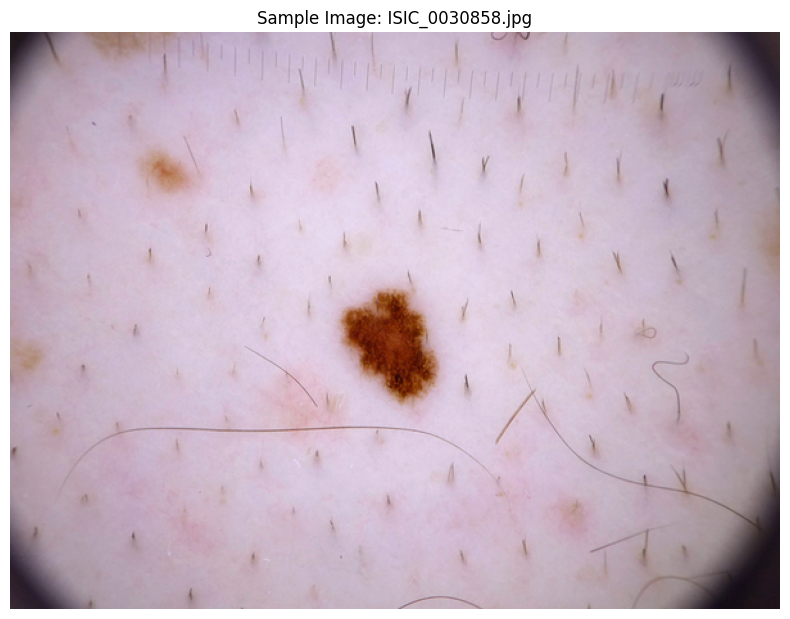

In [14]:
plt.figure(figsize=(8, 8))
plt.imshow(sample_image_rgb)
plt.title(f"Sample Image: {sample_image_path.name}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
df_labels.to_csv(DATA_DIR / "labels_with_class.csv", index=False)

In [16]:
data_summary = {
    "total_images": len(image_files),
    "total_labels": len(df_labels),
    "num_classes": len(class_columns),
    "class_columns": class_columns
}

data_summary["class_distribution"] = {k: int(v) for k, v in class_distribution.items()}

with open(DATA_DIR / "data_summary.json", "w") as f:
    json.dump(data_summary, f, indent=2)
    
print("Data summary saved.")

Data summary saved.
